# Model without User_Input

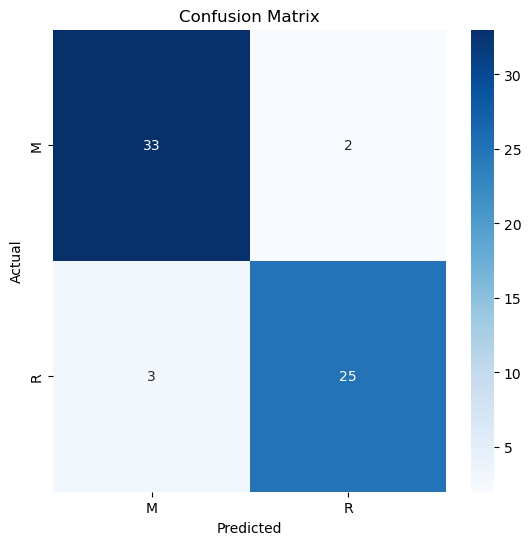

In [2]:
import tkinter as tk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

class SonarGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Sonar Rock vs Mine Classifier")
        self.root.geometry("900x600")

        # --- 1. Data & Model Initialization ---
        self.load_and_train_model()

        # --- 2. GUI Layout ---
        
        # Left Side: Controls
        self.control_frame = tk.Frame(root, padx=20, pady=20, bg="#f0f0f0")
        self.control_frame.pack(side=tk.LEFT, fill=tk.Y)

        tk.Label(self.control_frame, text="Control Panel", font=("Arial", 16, "bold"), bg="#f0f0f0").pack(pady=10)

        # Accuracy Label
        self.acc_label = tk.Label(self.control_frame, text=f"Model Accuracy:\n{self.accuracy*100:.2f}%", 
                                  font=("Arial", 14), fg="green", bg="#f0f0f0")
        self.acc_label.pack(pady=20)

        # Predict Button
        self.btn_predict = tk.Button(self.control_frame, text="Test Random Sample", 
                                     command=self.predict_random_sample, 
                                     font=("Arial", 12), bg="blue", fg="white", height=2, width=20)
        self.btn_predict.pack(pady=10)

        # Result Display Area
        tk.Label(self.control_frame, text="Prediction Result:", font=("Arial", 12, "bold"), bg="#f0f0f0").pack(pady=(30, 5))
        self.result_text = tk.StringVar()
        self.result_text.set("Ready...")
        self.lbl_result = tk.Label(self.control_frame, textvariable=self.result_text, 
                                   font=("Arial", 14), bg="white", width=20, height=3, relief="sunken")
        self.lbl_result.pack()

        # Right Side: Visualization
        self.plot_frame = tk.Frame(root, bg="white")
        self.plot_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.draw_confusion_matrix()

    def load_and_train_model(self):
        try:
            # Load Data (Ensure sonar.csv is in the same folder)
            df = pd.read_csv('sonar.csv', header=None)
            X = df.drop(60, axis=1)
            y = df[60]

            # Preprocessing
            self.le = LabelEncoder()
            y = self.le.fit_transform(y) 
            
            self.class_names = self.le.classes_ 

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

            # Scaling
            self.scaler = StandardScaler()
            self.X_train_scaled = self.scaler.fit_transform(X_train)
            self.X_test_scaled = self.scaler.transform(X_test)
            self.y_test = y_test

            # Training
            self.knn = KNeighborsClassifier(n_neighbors=3)
            self.knn.fit(self.X_train_scaled, y_train)

            # Evaluation
            predictions = self.knn.predict(self.X_test_scaled)
            self.accuracy = accuracy_score(y_test, predictions)
            self.cm = confusion_matrix(y_test, predictions)
            
            # Save test set for random sampling in GUI
            self.X_test_raw = X_test 
            self.y_test_raw = y_test

        except Exception as e:
            messagebox.showerror("Error", f"Could not load data: {e}")
            self.root.destroy()

    def draw_confusion_matrix(self):
        # Create a figure for the plot
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(self.cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=self.class_names, yticklabels=self.class_names, ax=ax)
        ax.set_title('Confusion Matrix')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')

        # Embed plot in Tkinter
        canvas = FigureCanvasTkAgg(fig, master=self.plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    def predict_random_sample(self):
        # Pick a random index from the test set
        random_idx = np.random.choice(self.X_test_raw.index)
        
        # Get the features and actual label
        sample_features = self.X_test_raw.loc[random_idx].values.reshape(1, -1)
        actual_label_idx = self.y_test_raw[self.X_test_raw.index.get_loc(random_idx)] # Get by integer loc
        actual_label_str = self.class_names[actual_label_idx]

        # Scale and Predict
        sample_scaled = self.scaler.transform(sample_features)
        prediction_idx = self.knn.predict(sample_scaled)[0]
        prediction_str = self.class_names[prediction_idx]

        # Update Display
        result_msg = f"Predicted: {prediction_str}\nActual: {actual_label_str}"
        self.result_text.set(result_msg)
        
        # Color coding
        if prediction_str == actual_label_str:
            self.lbl_result.config(fg="green") # Correct
        else:
            self.lbl_result.config(fg="red")   # Incorrect

# --- Main Application Loop ---
if __name__ == "__main__":
    root = tk.Tk()
    app = SonarGUI(root)
    root.mainloop()

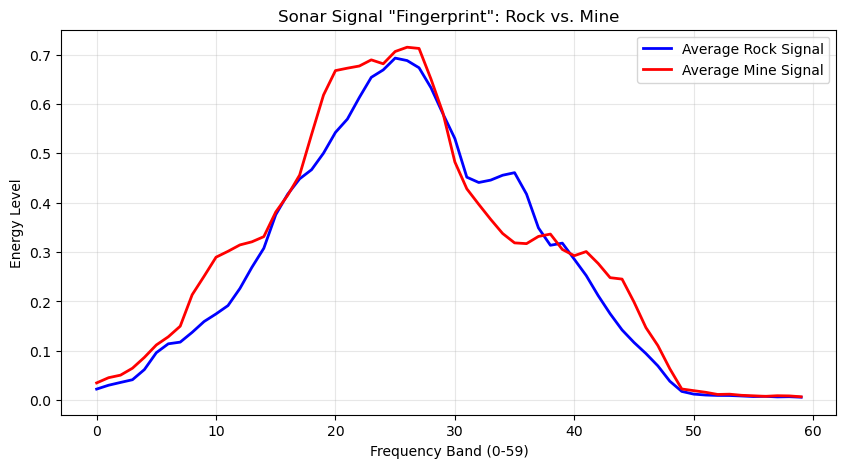

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('sonar.csv', header=None)

# 2. Calculate the average signal for Rocks vs. Mines
rock_avg = df[df[60] == 'R'].drop(60, axis=1).mean()
mine_avg = df[df[60] == 'M'].drop(60, axis=1).mean()

# 3. Plot
plt.figure(figsize=(10, 5))
plt.plot(rock_avg, label='Average Rock Signal', color='blue', linewidth=2)
plt.plot(mine_avg, label='Average Mine Signal', color='red', linewidth=2)

plt.title('Sonar Signal "Fingerprint": Rock vs. Mine')
plt.xlabel('Frequency Band (0-59)')
plt.ylabel('Energy Level')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Save
plt.savefig('signal_comparison.png')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_20176\1122887336.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[60], palette={'M': 'red', 'R': 'blue'})


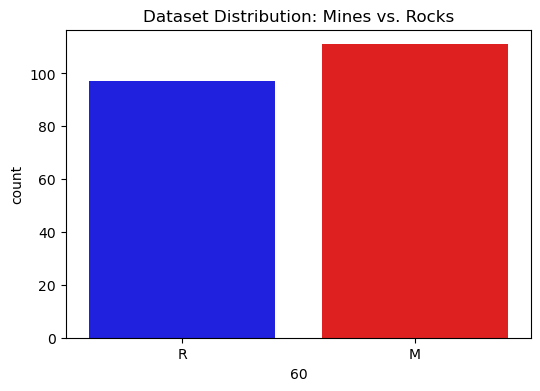

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x=df[60], palette={'M': 'red', 'R': 'blue'})
plt.title('Dataset Distribution: Mines vs. Rocks')
plt.savefig('class_distribution.png')
plt.show()
